In [ ]:
# download these before running any cells
import numpy as np
import pandas as pd
import matplotlib as plt

In [2]:
# auto-insurance fraud dataset
df = pd.read_csv('C:/Users/amanm/OneDrive/Desktop/dont open/Career/Breakthrough Team/Personal/fraud_oracle.csv')

In [3]:
df.columns

Index(['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea',
       'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex',
       'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory',
       'VehiclePrice', 'FraudFound_P', 'PolicyNumber', 'RepNumber',
       'Deductible', 'DriverRating', 'Days_Policy_Accident',
       'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle',
       'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType',
       'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year',
       'BasePolicy'],
      dtype='str')

In [4]:
# there is an imbalance in the this dataset where a majority of the labels are false fraud cases.
df['FraudFound_P'].value_counts()

FraudFound_P
0    14497
1      923
Name: count, dtype: int64

In [5]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum()) # only catches true blanks

(15420, 33)
Month                     str
WeekOfMonth             int64
DayOfWeek                 str
Make                      str
AccidentArea              str
DayOfWeekClaimed          str
MonthClaimed              str
WeekOfMonthClaimed      int64
Sex                       str
MaritalStatus             str
Age                     int64
Fault                     str
PolicyType                str
VehicleCategory           str
VehiclePrice              str
FraudFound_P            int64
PolicyNumber            int64
RepNumber               int64
Deductible              int64
DriverRating            int64
Days_Policy_Accident      str
Days_Policy_Claim         str
PastNumberOfClaims        str
AgeOfVehicle              str
AgeOfPolicyHolder         str
PoliceReportFiled         str
WitnessPresent            str
AgentType                 str
NumberOfSuppliments       str
AddressChange_Claim       str
NumberOfCars              str
Year                    int64
BasePolicy                st

In [6]:
df.head(5)

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [7]:
label = df['FraudFound_P']

so far, we know there are no missing values. a ton of strings so will most likely have to one hot encode categeorical variables when we choose our features. The biggest thing here is the definite class imbalance, there are so many more false cases then there are positive. 

Looking at individual features

In [8]:
# numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('FraudFound_P')  # remove the target variable from the list of numeric columns
df[numeric_cols].describe()

,WeekOfMonth,WeekOfMonthClaimed,Age,PolicyNumber,RepNumber,Deductible,DriverRating,Year
count,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,2.788586,2.693969,39.855707,7710.500000,8.483268,407.704280,2.487808,1994.866472
std,1.287585,1.259115,13.492377,4451.514911,4.599948,43.950998,1.119453,0.803313
min,1.000000,1.000000,0.000000,1.000000,1.000000,300.000000,1.000000,1994.000000
25%,2.000000,2.000000,31.000000,3855.750000,5.000000,400.000000,1.000000,1994.000000
50%,3.000000,3.000000,38.000000,7710.500000,8.000000,400.000000,2.000000,1995.000000
75%,4.000000,4.000000,48.000000,11565.250000,12.000000,400.000000,3.000000,1996.000000
max,5.000000,5.000000,80.000000,15420.000000,16.000000,700.000000,4.000000,1996.000000


What does the data tell us? (so far)
- minimum age is 0? --> this could mean missing values (placeholder?)
- policy number isn't important (i think)

array([[<Axes: title={'center': 'WeekOfMonth'}>,
        <Axes: title={'center': 'WeekOfMonthClaimed'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'PolicyNumber'}>,
        <Axes: title={'center': 'RepNumber'}>,
        <Axes: title={'center': 'Deductible'}>],
       [<Axes: title={'center': 'DriverRating'}>,
        <Axes: title={'center': 'Year'}>, <Axes: >]], dtype=object)

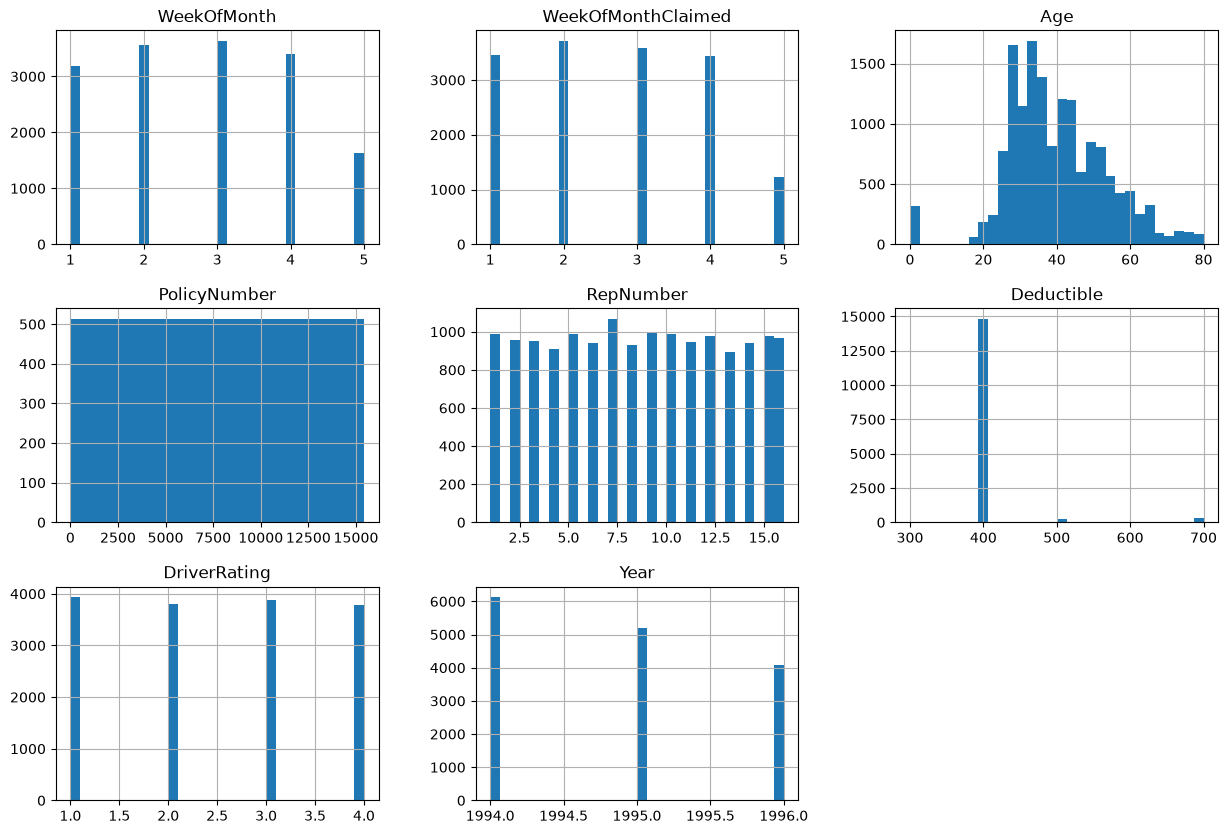

In [9]:
# numeric continued histogram
df[numeric_cols].hist(bins=30, figsize=(15, 10))
#

Categorical Values

In [10]:
categorical_cols = df.select_dtypes(include = 'object').columns.tolist()
categorical_cols

C:\Users\amanm\AppData\Local\Temp\ipykernel_25688\734830794.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include = 'object').columns.tolist()


['Month',
 'DayOfWeek',
 'Make',
 'AccidentArea',
 'DayOfWeekClaimed',
 'MonthClaimed',
 'Sex',
 'MaritalStatus',
 'Fault',
 'PolicyType',
 'VehicleCategory',
 'VehiclePrice',
 'Days_Policy_Accident',
 'Days_Policy_Claim',
 'PastNumberOfClaims',
 'AgeOfVehicle',
 'AgeOfPolicyHolder',
 'PoliceReportFiled',
 'WitnessPresent',
 'AgentType',
 'NumberOfSuppliments',
 'AddressChange_Claim',
 'NumberOfCars',
 'BasePolicy']

In [11]:
df[categorical_cols].describe()

,Month,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,Sex,MaritalStatus,Fault,PolicyType,...,PastNumberOfClaims,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,BasePolicy
count,15420,15420,15420,15420,15420,15420,15420,15420,15420,15420,...,15420,15420,15420,15420,15420,15420,15420,15420,15420,15420
unique,12,7,19,2,8,13,2,4,2,9,...,4,8,9,2,2,2,4,5,5,3
top,Jan,Monday,Pontiac,Urban,Monday,Jan,Male,Married,Policy Holder,Sedan - Collision,...,2 to 4,7 years,31 to 35,No,No,External,none,no change,1 vehicle,Collision
freq,1411,2616,3837,13822,3757,1446,13000,10625,11230,5584,...,5485,5807,5593,14992,15333,15179,7047,14324,14316,5962


In [12]:
# for col in categorical_cols:
#     print(f"Value counts for {col}:")
#     print(df[col].value_counts())
#     print("\n")

print(df['Fault'].value_counts(normalize = True))
print(df['PolicyType'].value_counts(normalize = True))
print(df['VehicleCategory'].value_counts(normalize = True))
print(df['VehiclePrice'].value_counts(normalize = True))


Fault
Policy Holder    0.728275
Third Party      0.271725
Name: proportion, dtype: float64
PolicyType
Sedan - Collision       0.362127
Sedan - Liability       0.323411
Sedan - All Perils      0.265045
Sport - Collision       0.022568
Utility - All Perils    0.022049
Utility - Collision     0.001946
Sport - All Perils      0.001427
Utility - Liability     0.001362
Sport - Liability       0.000065
Name: proportion, dtype: float64
VehicleCategory
Sedan      0.627173
Sport      0.347471
Utility    0.025357
Name: proportion, dtype: float64
VehiclePrice
20000 to 29000     0.523930
30000 to 39000     0.229118
more than 69000    0.140337
less than 20000    0.071077
40000 to 59000     0.029896
60000 to 69000     0.005642
Name: proportion, dtype: float64


In [13]:
print(df.duplicated().sum()) # we have no duplicated rows


0


In [28]:
df['PolicyNumber'].nunique() == len(df)
# policy number is just an ID, no need for it in the model, we can drop it

True

In [15]:
print('Age With Rows = 0:', (df['Age'] == 0).sum()) # there are 320 rows with age = 0, which is not possible. will most likely have to drop these rows from the dataset.

# do the same thing in categorical_cols
for col in categorical_cols:
    zero_count = (df[col] == '0').sum()
    if zero_count > 0:
        print(col + ':', zero_count)

print(df[df['DayOfWeekClaimed'] == '0']) # these two cols have 1 row with a value of 0, which is not possible. They are both the same row, so most likely ill just drop that row
print(df[df['MonthClaimed'] == '0'])

Age With Rows = 0: 320
DayOfWeekClaimed: 1
MonthClaimed: 1
     Month  WeekOfMonth DayOfWeek   Make AccidentArea DayOfWeekClaimed  \
1516   Jul            2    Monday  Honda        Rural                0   

     MonthClaimed  WeekOfMonthClaimed   Sex MaritalStatus  ...  AgeOfVehicle  \
1516            0                   1  Male        Single  ...           new   

     AgeOfPolicyHolder PoliceReportFiled WitnessPresent AgentType  \
1516          16 to 17                No             No  External   

      NumberOfSuppliments  AddressChange_Claim  NumberOfCars  Year  BasePolicy  
1516                 none            no change     1 vehicle  1994  All Perils  

[1 rows x 33 columns]
     Month  WeekOfMonth DayOfWeek   Make AccidentArea DayOfWeekClaimed  \
1516   Jul            2    Monday  Honda        Rural                0   

     MonthClaimed  WeekOfMonthClaimed   Sex MaritalStatus  ...  AgeOfVehicle  \
1516            0                   1  Male        Single  ...           new  

In [16]:
# full categorical value counts
with open('categorical_value_counts.txt', 'w') as f:
    for col in categorical_cols:
        f.write(f"--- {col} ---\n")
        f.write(df[col].value_counts(normalize=True).to_string())
        f.write("\n\n")

Learned Materials --> From Categorical Value Counts

1. Month, DayOfWeek are both spread fairly even
2. There are groups dominated by one value --> for example, AccidentArea is mainly Urban (90%), and Sex is mainly male (84%). Dominance doesn't mean useless, some of these have a strong fraud signal
3. Marital Status --> Married is 93% of the data
4. Policy Type --> has categories with 1 single row (sport - liability) --> which could mean 0% fraud or 100% fraud
5. AgeOfWehicle/AgeOfPolicyHolder --> confirms ordinal bins. Age of vehicles skews heavy toward "7 years more than 6 7" (86%), age of policy holders clusters around 31-50 (81%)
6. 0 place holder is in DayOweekCliamed and Month Claimed --> 1 row

In [17]:
# checking the mean of the target variable for each categorical column to see if there are any patterns or relationships between the categorical variables and the target variable.
with open('categorical_relationships.txt', 'w') as f:
    for col in categorical_cols:
        f.write(f"--- {col} ---\n")
        f.write(df.groupby(col)['FraudFound_P'].agg(['mean','count']).sort_values('mean', ascending=False).to_string())
        f.write("\n\n")

Count --> Number of times category shows up 
Mean --> Percentage of fraud in those counts 

Strongest signals (fraud rate far from the ~6% baseline, with meaningful sample size):

These are strongest possible features because they have categories with higher percetnags of fraud rates then our baseline (6%)

Fault: Policy Holder 7.9% vs Third Party 0.9% 
BasePolicy: All Perils 10.2% vs Liability 0.7% 
PolicyType: Liability-based policies (Sedan - Liability 0.7%, Utility - Liability 0%) are consistently near zero, while All Perils/Collision types run 7–14%. 
VehicleCategory: Sport 1.6% vs Utility 11.3%, both with solid sample sizes (5,358 and 391).
AgentType: External 6.1% vs Internal 1.7% — Internal only has 241 rows, smaller but still a decent sample.

smaller samples:

Make: "Mecedes" 25% fraud on just 4 rows, "Jaguar"/"Lexus"/"Ferrari"/"Porche" at 0% fraud on 1–6 rows each. None of these are trustworthy — too few claims to say anything real about that brand.
AddressChange_Claim "under 6 months": 75% on 4 rows — same problem as before, noise not signal.
PolicyType "Sport - Liability": 0% on 1 row — meaningless.
Days_Policy_Claim "8 to 15" (21 rows) and "none" (1 row) — too thin to trust.

Moderate, worth keeping: AccidentArea, PastNumberOfClaims, AgeOfPolicyHolder (younger policyholders 21–25 show 14.8% vs older groups ~5%), WitnessPresent, PoliceReportFiled — all show real movement with reasonably-sized groups on both sides.

In [18]:
# numeric correlation
df[numeric_cols + ['FraudFound_P']].corr()['FraudFound_P']

WeekOfMonth          -0.011861
WeekOfMonthClaimed   -0.005761
Age                  -0.029741
PolicyNumber         -0.020345
RepNumber            -0.007551
Deductible            0.017348
DriverRating          0.007266
Year                 -0.024760
FraudFound_P          1.000000
Name: FraudFound_P, dtype: float64

Correlation ranges from -1 - 1
Closer to 0 means no linear relationships
1 --> strong pos relationship
-1 --> strong neg relationship 
magnitude matters --> +0.5 means more than -.005

From the data it seems a lot of this numeric data doesn't seem to have a strong linear relationship. It seems that the majority of predictive signals are coming from our categorical columns 
---> Fault, BasePolicy, PolicyType, VehicleCategory, AgentType, plus moderate signal from AccidentArea, PastNumberOfClaims, AgeOfPolicyHolder, WitnessPresent, PoliceReportFiled.

numeric columns seem flat

In [19]:
# flagging which numeric cols could be more categorical than numeric based on the number of unique values in each column
# then check their fraud rate

for col in numeric_cols:
    print(col, df[col].nunique())

for col in ['Deductible', 'DriverRating', 'Year', 'WeekOfMonth', 'WeekOfMonthClaimed']:
    print(f"--- {col} ---")
    print(df.groupby(col)['FraudFound_P'].agg(['mean', 'count']))
    print()

WeekOfMonth 5
WeekOfMonthClaimed 5
Age 66
PolicyNumber 15420
RepNumber 16
Deductible 4
DriverRating 4
Year 3
--- Deductible ---
                mean  count
Deductible                 
300         0.250000      8
400         0.057690  14838
500         0.178707    263
700         0.057878    311

--- DriverRating ---
                  mean  count
DriverRating                 
1             0.058824   3944
2             0.056301   3801
3             0.062307   3884
4             0.061989   3791

--- Year ---
          mean  count
Year                 
1994  0.066591   6142
1995  0.057940   5195
1996  0.052168   4083

--- WeekOfMonth ---
                 mean  count
WeekOfMonth                 
1            0.062755   3187
2            0.063238   3558
3            0.059066   3640
4            0.056504   3398
5            0.055589   1637

--- WeekOfMonthClaimed ---
                        mean  count
WeekOfMonthClaimed                 
1                   0.063768   3450
2                 

Outside of Deductible --> the rest of these seem to be flat

Deductible has some interesting parts --> 300 shows 25% fraud but only 8 rows --> could be noisy --> The two large groups (400 at 5.8%, 700 at 5.8%) are basically identical, and 500 (263 rows) sits a bit higher at 17.9% — that group has enough rows to be worth a second look, though still much smaller than the two dominant groups

# Cleaning The Data

In [20]:
# make a copy 
df_copy = df.copy()
label = df_copy['FraudFound_P']

In [21]:
# dropping that one row with 0 value in DayOfWeekClaimed and MonthClaimed
df_copy = df_copy[df_copy['DayOfWeekClaimed'] != '0'].reset_index(drop=True) 
# reseting the index after dropping the row keeps the index in order not just a missing number in the rows


In [22]:
# decide what to do with the Age col since some of those rows have fraud found P = 1 in them
print(df[df['Age'] == 0]['FraudFound_P'].mean())
print(df[df['Age'] == 0]['FraudFound_P'].sum())

0.096875
31


In [23]:
print(df[df['Age']==0][['Age','AgeOfPolicyHolder']].head(320))
print(df[df['Age']==51][['Age','AgeOfPolicyHolder']].head(120))

       Age AgeOfPolicyHolder
7        0          16 to 17
13       0          16 to 17
28       0          16 to 17
31       0          16 to 17
58       0          16 to 17
...    ...               ...
15243    0          16 to 17
15262    0          16 to 17
15274    0          16 to 17
15379    0          16 to 17
15392    0          16 to 17

[320 rows x 2 columns]
      Age AgeOfPolicyHolder
123    51          41 to 50
140    51          41 to 50
249    51          41 to 50
264    51          41 to 50
346    51          41 to 50
...   ...               ...
5923   51          41 to 50
5942   51          41 to 50
5972   51          41 to 50
6002   51          41 to 50
6010   51          41 to 50

[120 rows x 2 columns]


In [24]:
print(df[df['Age']==0]['AgeOfPolicyHolder'].value_counts())
print(df[(df['AgeOfPolicyHolder']=='18 to 20') & (df['Age']!=0)]['Age'].value_counts())
print(df[(df['AgeOfPolicyHolder']=='21 to 25') & (df['Age']!=0)]['Age'].value_counts().sort_index())

AgeOfPolicyHolder
16 to 17    320
Name: count, dtype: int64
Age
16    9
17    6
Name: count, dtype: int64
Age
18    48
19    32
20    28
Name: count, dtype: int64


In [27]:
df_copy['age_was_missing'] = df_copy['Age'] == 0 # put a flag over all the age was missing rows (0)
df_copy.loc[df_copy['Age']==0, 'Age'] = 16
# minimum driving age

# check 
print((df_copy['Age']==0).sum())          # should be 0 now
print(df_copy['age_was_missing'].sum())   # should be 320
print(df_copy['Age'].describe())          # min should now be 16, not 0

# make sure df never changed
print((df['Age'] == 0).sum())

0
0
count    15419.000000
mean        40.189312
std         12.678745
min         16.000000
25%         31.000000
50%         38.000000
75%         48.000000
max         80.000000
Name: Age, dtype: float64
320


In [26]:
# final checks before feature selection
print(df_copy.shape)
print(df_copy.isnull().sum().sum())
print(df_copy.duplicated().sum())
print((df_copy['Age']==0).sum())
print(df_copy['Age'].describe())
print(df_copy['age_was_missing'].sum())

(15419, 34)
0
0
0
count    15419.000000
mean        40.189312
std         12.678745
min         16.000000
25%         31.000000
50%         38.000000
75%         48.000000
max         80.000000
Name: Age, dtype: float64
319
